# Epidemiological Intelligence — Modelagem Estatística: Insuficiência Cardíaca

## Objetivo

Modela a relação entre variáveis climáticas e o número mensal de casos de **insuficiência
cardíaca** nos municípios do RS, seguindo a metodologia de `02_modeling.ipynb`
(`MODELING_SPEC.md`). Compara OLS e Poisson (baselines) com Binomial Negativa (modelo principal,
dada a forte sobredispersão), com efeitos fixos de município e mês, testando em seguida variáveis
climáticas atuais e defasadas (1–3 meses).

Validação sempre temporal (treino < 2024-01-01, teste 2024-01 a 2025-12), nunca aleatória.
Funções compartilhadas em `data_science/src/modeling_utils.py`.

**Nota de linguagem:** as interpretações abaixo descrevem associações estatísticas e ganhos de
desempenho preditivo fora da amostra — nunca relações causais.


In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
import statsmodels.formula.api as smf

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import modeling_utils as mu

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)

## 1. Carregamento dos dados

Dados de `epidemiology_climate_monthly`, com cache local em parquet (leitura apenas, sem
gravação no BigQuery).


In [2]:
df = mu.load_raw_data()
print("Shape:", df.shape)
df.columns.tolist()

Shape: (21384, 19)


['municipality',
 'year',
 'month',
 'municipality_code',
 'reference_date',
 'cases',
 'source_file',
 'ingestion_timestamp',
 'disease',
 'precipitation_sum_mm',
 'precipitation_avg_observation_mm',
 'precipitation_max_observation_mm',
 'temperature_avg_c',
 'dew_point_avg_c',
 'relative_humidity_avg_pct',
 'atmospheric_pressure_avg_mb',
 'wind_speed_avg_ms',
 'wind_gust_max_ms',
 'station_count']

In [3]:
# A função já converte reference_date para datetime; confirmando aqui
print(df["reference_date"].dtype)
df["reference_date"].head()

datetime64[ms]


0   2015-01-01
1   2015-01-01
2   2015-01-01
3   2015-01-01
4   2015-01-01
Name: reference_date, dtype: datetime64[ms]

## 2. Lags climáticos

Lags construídos em tabela auxiliar por município/mês (`build_climate_monthly_lags`), cacheada em
`data_science/data/processed/climate_monthly_lags.parquet`. Validações de conflitos, duplicatas e
quebras na sequência mensal são reproduzidas abaixo para manter o notebook auditável.


In [4]:
climate_monthly = mu.build_climate_monthly_lags(df)
print("Shape climate_monthly:", climate_monthly.shape)
lag_cols = [c for c in climate_monthly.columns if "_lag" in c]
print("Número de colunas de lag:", len(lag_cols))

Shape climate_monthly: (3564, 38)
Número de colunas de lag: 27


In [5]:
# Validação 1: conflitos de valores climáticos para o mesmo município/mês
climate_cols = ["municipality", "reference_date"] + mu.CLIMATE_VARS
climate_conflicts = (
    df[climate_cols]
    .groupby(["municipality", "reference_date"])
    .nunique(dropna=False)
)
conflict_count = int((climate_conflicts > 1).any(axis=1).sum())
print("Município/mês com valores climáticos conflitantes:", conflict_count)

# Validação 2: duplicatas município/mês na tabela climática
duplicates = int(climate_monthly.duplicated(subset=["municipality", "reference_date"]).sum())
print("Duplicatas município/mês:", duplicates)

# Validação 3: quebras na sequência mensal por município
check_dates = climate_monthly[["municipality", "reference_date"]].sort_values(
    ["municipality", "reference_date"]
).copy()
check_dates["previous_date"] = check_dates.groupby("municipality")["reference_date"].shift(1)
check_dates["month_difference"] = (
    (check_dates["reference_date"].dt.year * 12 + check_dates["reference_date"].dt.month)
    - (check_dates["previous_date"].dt.year * 12 + check_dates["previous_date"].dt.month)
)
date_gaps = check_dates[
    check_dates["previous_date"].notna() & (check_dates["month_difference"] != 1)
]
print("Quebras na sequência mensal:", len(date_gaps))

Município/mês com valores climáticos conflitantes: 0
Duplicatas município/mês: 0
Quebras na sequência mensal: 0


In [6]:
# Exemplo de lags para Porto Alegre (temperatura)
check_climate = climate_monthly[climate_monthly["municipality"] == "PORTO ALEGRE"][
    ["reference_date", "temperature_avg_c", "temperature_avg_c_lag1",
     "temperature_avg_c_lag2", "temperature_avg_c_lag3"]
].sort_values("reference_date")

display(check_climate.head(12))

,reference_date,temperature_avg_c,temperature_avg_c_lag1,temperature_avg_c_lag2,temperature_avg_c_lag3
1716,2015-01-01,25.451344,NaN,NaN,NaN
1717,2015-02-01,24.657589,25.451344,NaN,NaN
1718,2015-03-01,23.838038,24.657589,25.451344,NaN
1719,2015-04-01,21.052222,23.838038,24.657589,25.451344
1720,2015-05-01,18.313844,21.052222,23.838038,24.657589
1721,2015-06-01,15.567419,18.313844,21.052222,23.838038
1722,2015-07-01,15.573925,15.567419,18.313844,21.052222
1723,2015-08-01,20.317070,15.573925,15.567419,18.313844
1724,2015-09-01,17.169735,20.317070,15.573925,15.567419
1725,2015-10-01,18.522446,17.169735,20.317070,15.573925


In [7]:
df = mu.merge_climate_lags(df, climate_monthly)
print("Shape df após merge dos lags:", df.shape)

DISEASE_PREVIEW = mu.DISEASES["insuficiencia_cardiaca"]
check_lags = df[
    (df["municipality"] == "PORTO ALEGRE") & (df["disease"] == DISEASE_PREVIEW)
][
    ["reference_date", "cases", "atmospheric_pressure_avg_mb", "atmospheric_pressure_avg_mb_lag1",
     "atmospheric_pressure_avg_mb_lag2", "atmospheric_pressure_avg_mb_lag3"]
].sort_values("reference_date")

display(check_lags.head(12))

Shape df após merge dos lags: (21384, 46)


,reference_date,cases,atmospheric_pressure_avg_mb,atmospheric_pressure_avg_mb_lag1,atmospheric_pressure_avg_mb_lag2,atmospheric_pressure_avg_mb_lag3
82,2015-01-01,210,1007.278495,NaN,NaN,NaN
244,2015-02-01,184,1007.068601,1007.278495,NaN,NaN
406,2015-03-01,249,1008.724194,1007.068601,1007.278495,NaN
568,2015-04-01,224,1010.940139,1008.724194,1007.068601,1007.278495
730,2015-05-01,260,1012.569758,1010.940139,1008.724194,1007.068601
892,2015-06-01,248,1013.892525,1012.569758,1010.940139,1008.724194
1054,2015-07-01,251,1012.587231,1013.892525,1012.569758,1010.940139
1216,2015-08-01,234,1010.367742,1012.587231,1013.892525,1012.569758
1378,2015-09-01,278,1008.852301,1010.367742,1012.587231,1013.892525
1540,2015-10-01,279,1009.656720,1008.852301,1010.367742,1012.587231


## 3. Split temporal

Corte sempre temporal: treino com `reference_date < 2024-01-01`, teste entre 2024-01 e 2025-12.


In [8]:
train_df, test_df = mu.temporal_split(df)

print("Treino:", train_df["reference_date"].min(), "→", train_df["reference_date"].max())
print("Teste: ", test_df["reference_date"].min(), "→", test_df["reference_date"].max())
print("Treino shape:", train_df.shape)
print("Teste shape: ", test_df.shape)

Treino: 2015-01-01 00:00:00 → 2023-12-01 00:00:00
Teste:  2024-01-01 00:00:00 → 2025-12-01 00:00:00
Treino shape: (17496, 46)
Teste shape:  (3888, 46)


## 4. Filtragem da doença

Doença modelada: **INSUFICIÊNCIA CARDÍACA**. `prepare_disease_frame` filtra a doença e ajusta os
tipos exigidos por `patsy`/`statsmodels`, sem preencher ausentes com zero (`dropna` apenas nas
colunas exigidas por cada modelo).


In [9]:
DISEASE = mu.DISEASES["insuficiencia_cardiaca"]
print("Doença:", DISEASE)

train_disease0 = mu.prepare_disease_frame(train_df, DISEASE)
test_disease0 = mu.prepare_disease_frame(test_df, DISEASE)

print("Treino (doença):", train_disease0.shape)
print("Teste (doença): ", test_disease0.shape)
print("Municípios no treino:", train_disease0["municipality"].nunique())
print("Municípios no teste: ", test_disease0["municipality"].nunique())

Doença: INSUFICIÊNCIA CARDÍACA
Treino (doença): (2916, 46)
Teste (doença):  (648, 46)
Municípios no treino: 27
Municípios no teste:  27


## 5. Baseline simples, OLS, Poisson e Binomial Negativa simples

Reproduz de forma compacta a comparação metodológica do notebook de referência: baseline pela
média histórica, OLS e Poisson com temperatura média como única variável, checagem de
sobredispersão e Binomial Negativa simples com alpha estimado — apenas para justificar a escolha
da Binomial Negativa como modelo principal.


In [10]:
train_simple = train_disease0.copy()
test_simple = test_disease0.copy()

baseline_prediction = train_simple["cases"].mean()
test_simple["baseline_pred"] = baseline_prediction

baseline_mae = mean_absolute_error(test_simple["cases"], test_simple["baseline_pred"])
baseline_rmse = np.sqrt(mean_squared_error(test_simple["cases"], test_simple["baseline_pred"]))

print("Média histórica (treino):", baseline_prediction)
print("Baseline MAE:", baseline_mae)
print("Baseline RMSE:", baseline_rmse)

Média histórica (treino): 20.374828532235938
Baseline MAE: 23.08976549137157
Baseline RMSE: 57.6821704093314


In [11]:
ols_simple = smf.ols(formula="cases ~ temperature_avg_c", data=train_simple).fit()
print(ols_simple.summary())

                            OLS Regression Results                            
Dep. Variable:                  cases   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     1.985
Date:                Wed, 26 Aug 2026   Prob (F-statistic):              0.159
Time:                        19:16:41   Log-Likelihood:                -15296.
No. Observations:                2844   AIC:                         3.060e+04
Df Residuals:                    2842   BIC:                         3.061e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            14.1374      4.73

In [12]:
test_simple["ols_pred"] = ols_simple.predict(test_simple)
ols_eval = test_simple[test_simple["cases"].notna() & test_simple["ols_pred"].notna()].copy()

ols_mae = mean_absolute_error(ols_eval["cases"], ols_eval["ols_pred"])
ols_rmse = np.sqrt(mean_squared_error(ols_eval["cases"], ols_eval["ols_pred"]))

print("OLS MAE:", ols_mae)
print("OLS RMSE:", ols_rmse)
print("Previsões negativas:", (ols_eval["ols_pred"] < 0).sum())

OLS MAE: 24.32471668350305
OLS RMSE: 60.28752131722783
Previsões negativas: 0


In [13]:
poisson_simple = smf.glm(
    formula="cases ~ temperature_avg_c", data=train_simple, family=sm.families.Poisson()
).fit()

test_simple["poisson_pred"] = poisson_simple.predict(test_simple)
poisson_eval = test_simple[test_simple["cases"].notna() & test_simple["poisson_pred"].notna()].copy()

poisson_mae = mean_absolute_error(poisson_eval["cases"], poisson_eval["poisson_pred"])
poisson_rmse = np.sqrt(mean_squared_error(poisson_eval["cases"], poisson_eval["poisson_pred"]))

dispersion = poisson_simple.pearson_chi2 / poisson_simple.df_resid

print("Poisson MAE:", poisson_mae)
print("Poisson RMSE:", poisson_rmse)
print("Dispersão (Pearson chi2 / df_resid):", dispersion)

Poisson MAE: 24.329160389428655
Poisson RMSE: 60.28828595372323
Dispersão (Pearson chi2 / df_resid): 132.6194323261579


In [14]:
nb_estimated = smf.negativebinomial(formula="cases ~ temperature_avg_c", data=train_simple).fit(disp=False)
print(nb_estimated.summary())

test_simple["nb_pred"] = nb_estimated.predict(test_simple)
nb_eval = test_simple[test_simple["cases"].notna() & test_simple["nb_pred"].notna()].copy()

nb_mae = mean_absolute_error(nb_eval["cases"], nb_eval["nb_pred"])
nb_rmse = np.sqrt(mean_squared_error(nb_eval["cases"], nb_eval["nb_pred"]))

print("NB (alpha estimado) MAE:", nb_mae)
print("NB (alpha estimado) RMSE:", nb_rmse)

                     NegativeBinomial Regression Results                      
Dep. Variable:                  cases   No. Observations:                 2844
Model:               NegativeBinomial   Df Residuals:                     2842
Method:                           MLE   Df Model:                            1
Date:                Wed, 26 Aug 2026   Pseudo R-squ.:               0.0003485
Time:                        19:16:41   Log-Likelihood:                -11295.
converged:                       True   LL-Null:                       -11299.
Covariance Type:            nonrobust   LLR p-value:                  0.005009
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             2.7012      0.118     22.853      0.000       2.469       2.933
temperature_avg_c     0.0173      0.006      2.806      0.005       0.005       0.029
alpha                 1.


NB (alpha estimado) MAE: 24.334033943758453
NB (alpha estimado) RMSE: 60.288964856426794


### Por que migrar para Binomial Negativa com efeitos de município e mês

O baseline pela média histórica teve MAE ≈ 23,09 e RMSE ≈ 57,68. OLS, Poisson e Binomial Negativa
simples (só temperatura) tiveram desempenho **pior** que esse baseline (MAE ≈ 24,32–24,33, RMSE ≈
60,29): um único preditor climático não captura a heterogeneidade de volume entre municípios nem a
sazonalidade.

A razão qui-quadrado de Pearson / graus de liberdade do Poisson foi ≈ 132,6 (esperado ≈ 1 sob
equidispersão) — forte sobredispersão, justificando Binomial Negativa com alpha estimado (nunca
fixado em 1) como modelo principal, controlando por município e mês antes de avaliar clima.


## 6. Modelo-base Binomial Negativa (município + mês)

Modelo de referência: `cases ~ C(municipality) + C(month)`, ajustado com `smf.negativebinomial`
(alpha estimado, `method="bfgs"`, `maxiter=500`). Todas as variáveis climáticas das próximas
seções são comparadas contra este modelo-base.


In [15]:
base_model_preview = mu.fit_negbin(mu.BASE_FORMULA, train_disease0)
print("Convergiu:", base_model_preview.mle_retvals.get("converged", False))
print("Alpha:", base_model_preview.params.get("alpha"))

base_pred_preview = base_model_preview.predict(test_disease0)
base_metrics_preview = mu.regression_metrics(test_disease0["cases"], base_pred_preview)
print("Métricas do modelo-base (município + mês) no teste:")
base_metrics_preview

Convergiu: True
Alpha: 0.07603926649792599
Métricas do modelo-base (município + mês) no teste:


{'mae': 5.519087615511883,
 'rmse': 11.986848535591161,
 'r2': 0.9568153430938223,
 'wape_pct': 27.27762012700557}

### Correção metodológica: split dedicado para seleção de variáveis

Na primeira versão, os testes climáticos e de lag comparavam modelo-base vs. modelo+variável
treinando em `train_disease0` (< 2024) e avaliando no próprio `test_disease0` (2024–2025) — o
mesmo período depois usado para reportar a performance final. Isso infla o ganho reportado (viés
do "vencedor").

A correção usa `mu.feature_selection_split`: treino-para-seleção em 2015–2022
(`train_disease_fs`), validação em 2023 (`validation_disease_fs`) — nunca em `test_disease0`. O
modelo final continua treinado em todo o período < 2024 e avaliado em 2024–2025, como antes. Como
a seleção passa a olhar para um período diferente (2023, não 2024–2025), é esperado que a lista de
variáveis e os ganhos percentuais mudem em relação à primeira versão.


In [16]:
train_fs_df, validation_fs_df = mu.feature_selection_split(train_df)

train_disease_fs = mu.prepare_disease_frame(train_fs_df, DISEASE)
validation_disease_fs = mu.prepare_disease_frame(validation_fs_df, DISEASE)

print("Treino-para-seleção:", train_fs_df["reference_date"].min(), "→", train_fs_df["reference_date"].max())
print("Validação:          ", validation_fs_df["reference_date"].min(), "→", validation_fs_df["reference_date"].max())
print("Treino-para-seleção (doença):", train_disease_fs.shape)
print("Validação (doença):          ", validation_disease_fs.shape)

Treino-para-seleção: 2015-01-01 00:00:00 → 2022-12-01 00:00:00
Validação:           2023-01-01 00:00:00 → 2023-12-01 00:00:00
Treino-para-seleção (doença): (2592, 46)
Validação (doença):           (324, 46)


## 7. Contribuição individual das variáveis climáticas

Cada uma das 9 variáveis climáticas (`mu.CLIMATE_VARS`) é testada individualmente, comparando
modelo-base (`município + mês`) com modelo-base + variável, sobre as mesmas linhas válidas
(dropna por variável testada, não globalmente).


In [17]:
climate_results = mu.evaluate_candidate_features(train_disease_fs, validation_disease_fs, mu.CLIMATE_VARS)
display(climate_results.round(4))

,variable,train_n,test_n,coef,pvalue,alpha,base_mae,mae,mae_improvement_pct,base_rmse,rmse,rmse_improvement_pct,base_converged,converged
0,atmospheric_pressure_avg_mb,2523,314,0.0143,0.0282,0.0742,4.9830,4.6917,5.8476,9.4586,8.2726,12.5390,True,True
1,relative_humidity_avg_pct,2487,312,0.0092,0.0000,0.0718,4.9672,4.8847,1.6610,9.4754,9.2795,2.0674,True,True
2,dew_point_avg_c,2486,312,0.0215,0.0000,0.0735,4.9677,4.9124,1.1133,9.4739,9.2071,2.8159,True,True
3,precipitation_sum_mm,2444,313,0.0001,0.3651,0.0735,4.9810,4.9598,0.4257,9.4594,9.3810,0.8282,True,True
4,precipitation_avg_observation_mm,2444,313,0.0646,0.3839,0.0735,4.9810,4.9622,0.3782,9.4594,9.3848,0.7888,True,True
5,precipitation_max_observation_mm,2444,313,0.0002,0.8505,0.0736,4.9810,4.9685,0.2510,9.4594,9.4194,0.4224,True,True
6,temperature_avg_c,2530,314,-0.0081,0.1966,0.0740,4.9784,4.9812,-0.0572,9.4576,9.5000,-0.4480,True,True
7,wind_speed_avg_ms,2477,296,-0.0022,0.8781,0.0698,5.0795,5.0893,-0.1938,9.6750,9.7096,-0.3575,True,True
8,wind_gust_max_ms,2475,296,-0.0033,0.0984,0.0697,5.0791,5.2074,-2.5247,9.6655,10.1943,-5.4718,True,True


### Leitura dos resultados climáticos

Avaliadas na validação de 2023 (treino em 2015–2022), três variáveis combinam ganho real de
desempenho fora da amostra com significância estatística: **pressão atmosférica média** (MAE
−5,85%, RMSE −12,54%, p ≈ 0,028), **umidade relativa** (MAE −1,66%, RMSE −2,07%, p < 0,0001) e
**ponto de orvalho** (MAE −1,11%, RMSE −2,82%, p < 0,0001) — aqui significância e ganho preditivo
apontam na mesma direção para as três.

Temperatura média teve efeito pequeno e não significativo (p ≈ 0,197), piorando levemente o MAE.
Vento e precipitação não trouxeram ganho relevante — a rajada de vento chegou a piorar o MAE em
2,52% mesmo com p ≈ 0,098, reforçando que significância marginal isolada não justifica incluir uma
variável sem ganho preditivo real.


## 8. Escolha das variáveis para teste de defasagens (lags)

Selecionadas para o teste de lags: `atmospheric_pressure_avg_mb`, `relative_humidity_avg_pct` e
`dew_point_avg_c` (ganho real e significância na validação de 2023), e `temperature_avg_c` (sem
ganho, mas mantida pela plausibilidade epidemiológica). Escolha feita antes de olhar o resultado do
teste de lags, para não enviesar a seleção.


In [18]:
relevant_vars = [
    "atmospheric_pressure_avg_mb",
    "temperature_avg_c",
    "relative_humidity_avg_pct",
    "dew_point_avg_c",
]

lag_candidates = mu.lag_candidates(relevant_vars)
print("Variáveis testadas (atual + lag1 + lag2 + lag3):")
lag_candidates

Variáveis testadas (atual + lag1 + lag2 + lag3):


['atmospheric_pressure_avg_mb',
 'atmospheric_pressure_avg_mb_lag1',
 'atmospheric_pressure_avg_mb_lag2',
 'atmospheric_pressure_avg_mb_lag3',
 'temperature_avg_c',
 'temperature_avg_c_lag1',
 'temperature_avg_c_lag2',
 'temperature_avg_c_lag3',
 'relative_humidity_avg_pct',
 'relative_humidity_avg_pct_lag1',
 'relative_humidity_avg_pct_lag2',
 'relative_humidity_avg_pct_lag3',
 'dew_point_avg_c',
 'dew_point_avg_c_lag1',
 'dew_point_avg_c_lag2',
 'dew_point_avg_c_lag3']

In [19]:
lag_results = mu.evaluate_candidate_features(train_disease_fs, validation_disease_fs, lag_candidates)
display(lag_results.round(4))

C:\Users\eduar\Desktop\Projeto-Python\epidemiological-intelligence\.venv\Lib\site-packages\statsmodels\discrete\discrete_model.py:3379: RuntimeWarning: divide by zero encountered in log
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)
C:\Users\eduar\Desktop\Projeto-Python\epidemiological-intelligence\.venv\Lib\site-packages\statsmodels\discrete\discrete_model.py:3379: RuntimeWarning: invalid value encountered in multiply
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)


,variable,train_n,test_n,coef,pvalue,alpha,base_mae,mae,mae_improvement_pct,base_rmse,rmse,rmse_improvement_pct,base_converged,converged
0,atmospheric_pressure_avg_mb,2523,314,0.0143,0.0282,0.0742,4.9830,4.6917,5.8476,9.4586,8.2726,12.5390,True,True
1,atmospheric_pressure_avg_mb_lag1,2497,313,0.0072,0.2680,0.0733,4.9923,4.8467,2.9173,9.3773,8.7936,6.2241,True,True
2,relative_humidity_avg_pct,2487,312,0.0092,0.0000,0.0718,4.9672,4.8847,1.6610,9.4754,9.2795,2.0674,True,True
3,relative_humidity_avg_pct_lag1,2462,310,0.0072,0.0000,0.0719,4.9825,4.9099,1.4577,9.4071,9.2660,1.4999,True,True
4,dew_point_avg_c,2486,312,0.0215,0.0000,0.0735,4.9677,4.9124,1.1133,9.4739,9.2071,2.8159,True,True
5,dew_point_avg_c_lag1,2461,310,0.0198,0.0001,0.0726,4.9805,4.9477,0.6591,9.4027,9.1414,2.7788,True,True
6,dew_point_avg_c_lag2,2435,310,0.0178,0.0006,0.0735,4.9915,4.9830,0.1704,9.3488,9.2212,1.3652,True,True
7,temperature_avg_c_lag1,2504,313,-0.0019,0.7623,0.0734,4.9830,4.9803,0.0547,9.3706,9.3832,-0.1347,True,True
8,temperature_avg_c_lag3,2450,314,0.0073,0.2475,0.0738,4.9965,4.9955,0.0203,9.2561,9.2231,0.3571,True,True
9,temperature_avg_c_lag2,2477,314,-0.0012,0.8468,0.0740,4.9856,4.9852,0.0080,9.2924,9.3064,-0.1516,True,True


### Checagem de combinações multivariadas (ainda na validação de 2023)

As três variáveis com ganho e significância isolados (`atmospheric_pressure_avg_mb`,
`relative_humidity_avg_pct`, `dew_point_avg_c`) são testadas também em combinação — sempre
treinando em `train_disease_fs` e avaliando em `validation_disease_fs` — para checar
multicolinearidade e qual combinação generaliza melhor.


In [20]:
candidate_combinations = [
    ["atmospheric_pressure_avg_mb"],
    ["atmospheric_pressure_avg_mb", "relative_humidity_avg_pct"],
    ["atmospheric_pressure_avg_mb", "dew_point_avg_c"],
    ["relative_humidity_avg_pct", "dew_point_avg_c"],
    ["atmospheric_pressure_avg_mb", "relative_humidity_avg_pct", "dew_point_avg_c"],
]

combination_rows = []
for combo in candidate_combinations:
    combo_result = mu.fit_final_models(train_disease_fs, validation_disease_fs, combo)
    combo_model = combo_result["final_model"]
    combination_rows.append({
        "features": " + ".join(combo),
        "mae": combo_result["final_metrics"]["mae"],
        "rmse": combo_result["final_metrics"]["rmse"],
        "mae_improvement_pct": combo_result["mae_improvement_pct"],
        "rmse_improvement_pct": combo_result["rmse_improvement_pct"],
        "max_pvalue": max(combo_model.pvalues.get(f, np.nan) for f in combo),
        "converged": combo_result["final_converged"],
    })

combination_table = pd.DataFrame(combination_rows).sort_values("rmse_improvement_pct", ascending=False).reset_index(drop=True)
display(combination_table.round(4))

# Correlação entre as três variáveis candidatas (checagem de multicolinearidade)
display(train_disease_fs[["atmospheric_pressure_avg_mb", "relative_humidity_avg_pct", "dew_point_avg_c"]].corr().round(3))

C:\Users\eduar\Desktop\Projeto-Python\epidemiological-intelligence\.venv\Lib\site-packages\statsmodels\discrete\discrete_model.py:3379: RuntimeWarning: divide by zero encountered in log
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)
C:\Users\eduar\Desktop\Projeto-Python\epidemiological-intelligence\.venv\Lib\site-packages\statsmodels\discrete\discrete_model.py:3379: RuntimeWarning: invalid value encountered in multiply
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)
C:\Users\eduar\Desktop\Projeto-Python\epidemiological-intelligence\.venv\Lib\site-packages\statsmodels\discrete\discrete_model.py:3379: RuntimeWarning: divide by zero encountered in log
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)
C:\Users\eduar\Desktop\Projeto-Python\epidemiological-intelligence\.venv\Lib\site-packages\statsmodels\discrete\discrete_model.py:3379: RuntimeWarning: invalid value encountered in multiply
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)


C:\Users\eduar\Desktop\Projeto-Python\epidemiological-intelligence\.venv\Lib\site-packages\statsmodels\discrete\discrete_model.py:3379: RuntimeWarning: divide by zero encountered in log
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)
C:\Users\eduar\Desktop\Projeto-Python\epidemiological-intelligence\.venv\Lib\site-packages\statsmodels\discrete\discrete_model.py:3379: RuntimeWarning: invalid value encountered in multiply
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)


,features,mae,rmse,mae_improvement_pct,rmse_improvement_pct,max_pvalue,converged
0,atmospheric_pressure_avg_mb + dew_point_avg_c,4.2984,6.9241,13.5647,26.9082,0.0000,True
1,atmospheric_pressure_avg_mb + relative_humidit...,4.2952,7.0944,13.6281,25.1102,0.0537,True
2,atmospheric_pressure_avg_mb + relative_humidit...,4.4158,7.4844,11.1931,21.0069,0.0008,True
3,atmospheric_pressure_avg_mb,4.6917,8.2726,5.8476,12.5390,0.0282,True
4,relative_humidity_avg_pct + dew_point_avg_c,4.8814,9.2559,1.7377,2.3010,0.6179,True


,atmospheric_pressure_avg_mb,relative_humidity_avg_pct,dew_point_avg_c
atmospheric_pressure_avg_mb,1.000,-0.122,0.205
relative_humidity_avg_pct,-0.122,1.000,0.057
dew_point_avg_c,0.205,0.057,1.000


### Leitura dos resultados de lag

Pressão atmosférica **contemporânea** segue como melhor resultado isolado (MAE −5,85%, RMSE
−12,54%, p ≈ 0,028). Sua defasagem de 1 mês também melhora as métricas (MAE −2,92%, RMSE −6,22%),
mas não é significativa (p ≈ 0,268); defasagens de 2–3 meses pioram. A versão contemporânea é
preferível.

Umidade relativa e ponto de orvalho seguem significativos (p < 0,001) e com ganho real, tanto
contemporâneos quanto defasados em 1 mês — mas a versão contemporânea supera a defasada em ambos
(umidade: −1,66% vs. −1,46% de MAE; ponto de orvalho: −1,11% vs. −0,66%), então os lags não agregam
valor. Temperatura e suas defasagens seguem com efeito pequeno e não significativo em todos os
casos.


## 9. Seleção final de features (justificativa)

A escolha final considera conjuntamente desempenho fora da amostra, p-valor, coerência
epidemiológica, convergência e multicolinearidade — nunca apenas a melhor métrica isolada.
Comparação feita sobre a validação de 2023, nunca sobre `test_disease0`.

**Features selecionadas: `atmospheric_pressure_avg_mb` e `dew_point_avg_c`** (contemporâneas, sem
lag). Correlação baixa entre as três candidatas (todas < 0,21 em módulo), afastando preocupação
forte de multicolinearidade. A dupla pressão + ponto de orvalho teve o maior ganho de RMSE na
validação (≈ −26,9%, vs. ≈ −21,0% de pressão+umidade e ≈ −25,1% com as três juntas) e MAE
praticamente empatado com o modelo de três variáveis (≈ −13,6%), com ambos os coeficientes
altamente significativos (p < 0,001). Adicionar `relative_humidity_avg_pct` não trouxe ganho
adicional e reduziu a significância de `dew_point_avg_c` (p sobe a ≈ 0,05) — sinal de informação
redundante.

Pressão atmosférica e ponto de orvalho têm plausibilidade epidemiológica para insuficiência
cardíaca (tônus vascular, viscosidade sanguínea e estresse térmico, associados na literatura a
descompensações cardiovasculares). Defasagens, temperatura, vento e precipitação foram descartados
por não agregarem ganho preditivo real.


In [21]:
features_selecionadas = ["atmospheric_pressure_avg_mb", "dew_point_avg_c"]
features_selecionadas

['atmospheric_pressure_avg_mb', 'dew_point_avg_c']

## 10. Modelo multivariado final

Ajustado via `mu.fit_final_models`, que reajusta modelo-base e modelo final (`município + mês` +
`atmospheric_pressure_avg_mb` + `dew_point_avg_c`) sobre as mesmas linhas válidas. Treino/teste
seguem `train_disease0` (2015–2023) / `test_disease0` (2024–2025), sem uso da validação de 2023
usada apenas na seleção de features.


In [22]:
resultado = mu.fit_final_models(train_disease0, test_disease0, features_selecionadas)

print(resultado["final_model"].summary())

C:\Users\eduar\Desktop\Projeto-Python\epidemiological-intelligence\.venv\Lib\site-packages\statsmodels\discrete\discrete_model.py:3379: RuntimeWarning: divide by zero encountered in log
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)
C:\Users\eduar\Desktop\Projeto-Python\epidemiological-intelligence\.venv\Lib\site-packages\statsmodels\discrete\discrete_model.py:3379: RuntimeWarning: invalid value encountered in multiply
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)


                     NegativeBinomial Regression Results                      
Dep. Variable:                  cases   No. Observations:                 2790
Model:               NegativeBinomial   Df Residuals:                     2750
Method:                           MLE   Df Model:                           39
Date:                Wed, 26 Aug 2026   Pseudo R-squ.:                  0.2911
Time:                        19:16:46   Log-Likelihood:                -7875.0
converged:                       True   LL-Null:                       -11109.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                              coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------
Intercept                                 -29.6095      6.673     -4.437      0.000     -42.689     -16.530
C(municipality)[T.BENTO GONCALVES]          

In [23]:
final_model = resultado["final_model"]

print("Fórmula final:", resultado["formula"])
print("Convergiu (base):", resultado["base_converged"])
print("Convergiu (final):", resultado["final_converged"])
print("Alpha:", resultado["alpha"])
print("AIC:", final_model.aic)
print("Log-Likelihood:", final_model.llf)
print()
print("Coeficiente atmospheric_pressure_avg_mb:", final_model.params.get("atmospheric_pressure_avg_mb"))
print("p-valor atmospheric_pressure_avg_mb:", final_model.pvalues.get("atmospheric_pressure_avg_mb"))
print()
print("Métricas baseline (município + mês):", resultado["base_metrics"])
print("Métricas modelo final:              ", resultado["final_metrics"])
print()
print("Melhora MAE:", round(resultado["mae_improvement_pct"], 2), "%")
print("Melhora RMSE:", round(resultado["rmse_improvement_pct"], 2), "%")
print()
print("Treino (linhas):", len(resultado["train_final"]))
print("Teste (linhas): ", len(resultado["test_final"]))

Fórmula final: cases ~ C(municipality) + C(month) + atmospheric_pressure_avg_mb + dew_point_avg_c
Convergiu (base): True
Convergiu (final): True
Alpha: 0.07405696024157295
AIC: 15832.042318057545
Log-Likelihood: -7875.021159028773

Coeficiente atmospheric_pressure_avg_mb: 0.032410124047842236
p-valor atmospheric_pressure_avg_mb: 1.461234552722941e-06

Métricas baseline (município + mês): {'mae': 5.746052932325142, 'rmse': 12.475695358946867, 'r2': 0.9571572295641899, 'wape_pct': 26.627169573294324}
Métricas modelo final:               {'mae': 5.573611331659249, 'rmse': 11.99033131550045, 'r2': 0.9604259597157249, 'wape_pct': 25.82807638767638}

Melhora MAE: 3.0 %
Melhora RMSE: 3.89 %

Treino (linhas): 2790
Teste (linhas):  590


### Interpretação do modelo multivariado

Frente ao modelo-base (só município + mês), o modelo com pressão atmosférica e ponto de orvalho
reduziu o MAE de 5,75 para 5,57 (≈ 3,00%) e o RMSE de 12,48 para 11,99 (≈ 3,89%) no teste
(2024–2025). Convergiu adequadamente (alpha ≈ 0,074); os dois coeficientes climáticos são
positivos e altamente significativos (p < 0,0001), associados a mais casos previstos em meses de
pressão e ponto de orvalho mais altos — associação estatística, não causal. Nenhum município do
teste foi excluído.

Esse ganho (3,00%/3,89%) é **menor** do que o da primeira versão do notebook (4,04%/7,45%, com
apenas `atmospheric_pressure_avg_mb`, selecionada olhando para o próprio teste). É o resultado
esperado de corrigir o vazamento: a seleção agora não espia 2024–2025, então o ganho reportado
deixa de estar inflado pelo viés do "vencedor". O ganho preditivo continua real e moderado — a
maior parte da capacidade explicativa do modelo vem dos efeitos fixos de município e mês.


## 11. Backtest e gráficos

### A) Real vs previsto (global, 2024–2025)

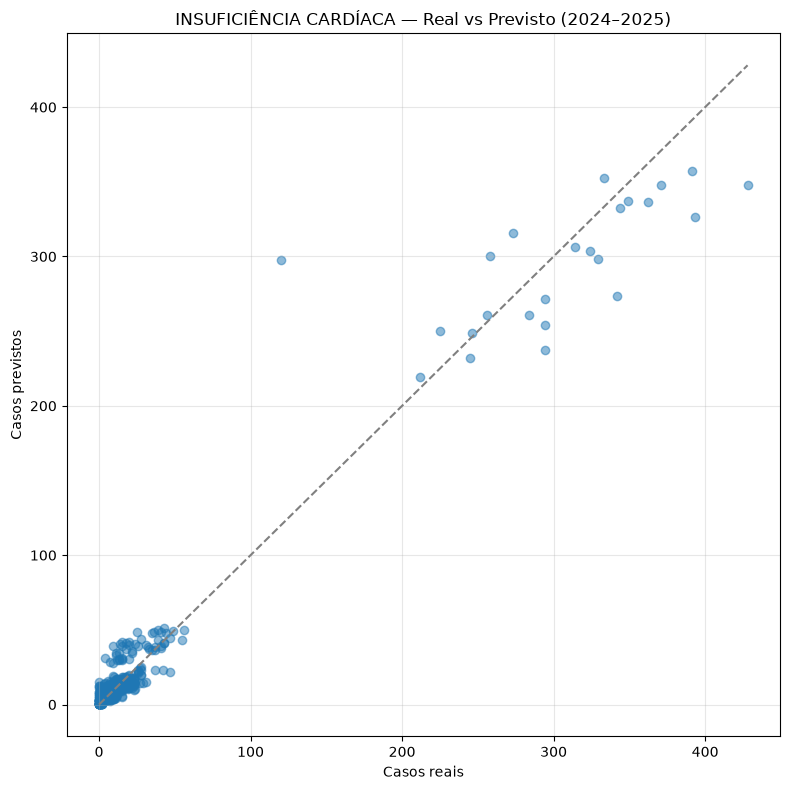

In [24]:
mu.plot_real_vs_predicted(resultado["test_final"]["cases"], resultado["final_pred"], DISEASE)

### B) Backtest temporal por município

`historical_df` contém o treino (2015–2023) e `forecast_df` o teste (2024–2025) com a coluna
`prediction`. Porto Alegre concentra o maior volume de casos; Passo Fundo e Rio Grande são o
segundo e terceiro municípios com mais casos acumulados.


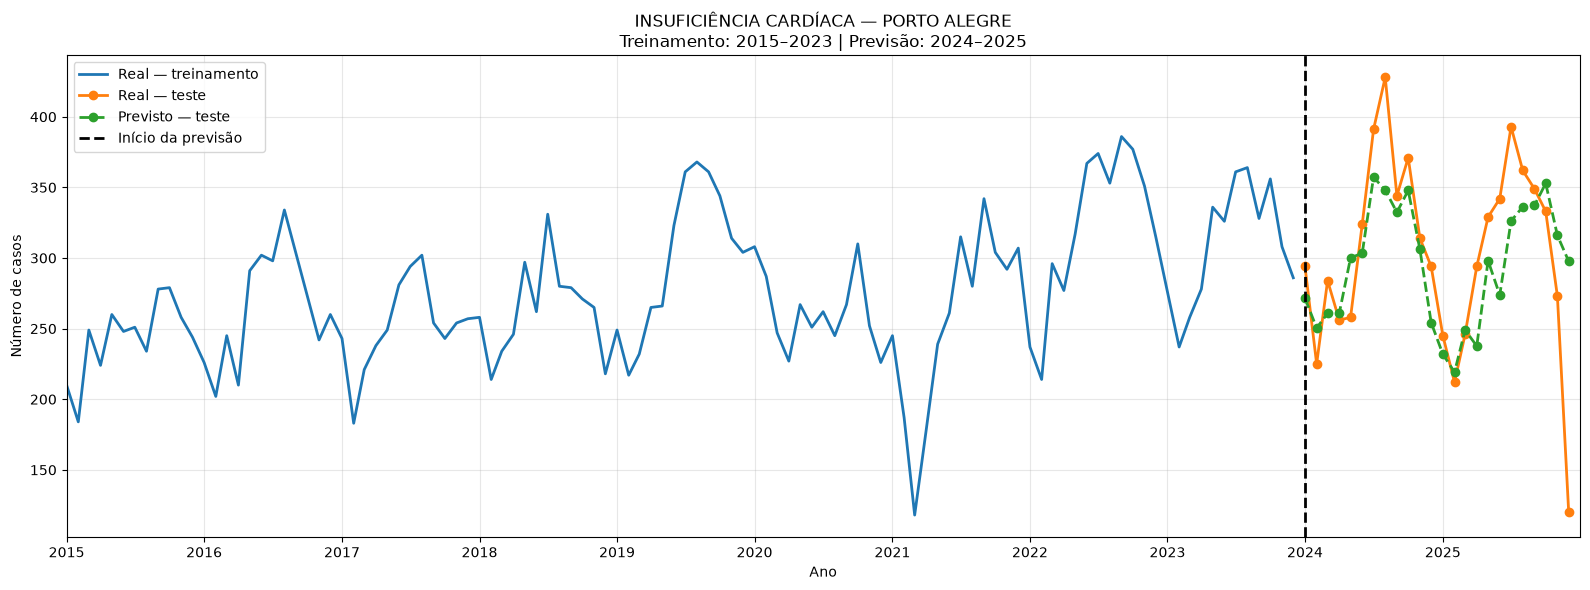

In [25]:
historical_df = train_disease0.copy()

forecast_df = resultado["test_final"].copy()
forecast_df["prediction"] = resultado["final_pred"]

plot_backtest = mu.make_backtest_plotter(DISEASE, historical_df, forecast_df)

plot_backtest("PORTO ALEGRE")

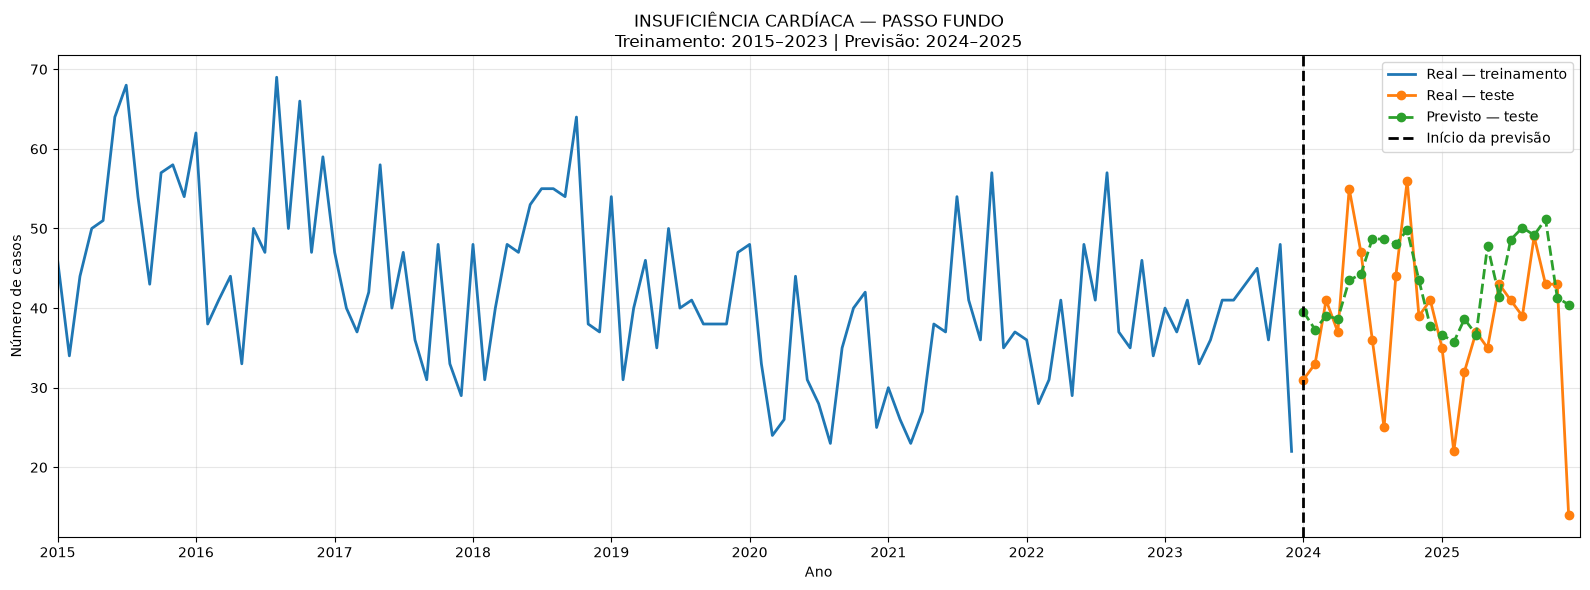

In [26]:
plot_backtest("PASSO FUNDO")

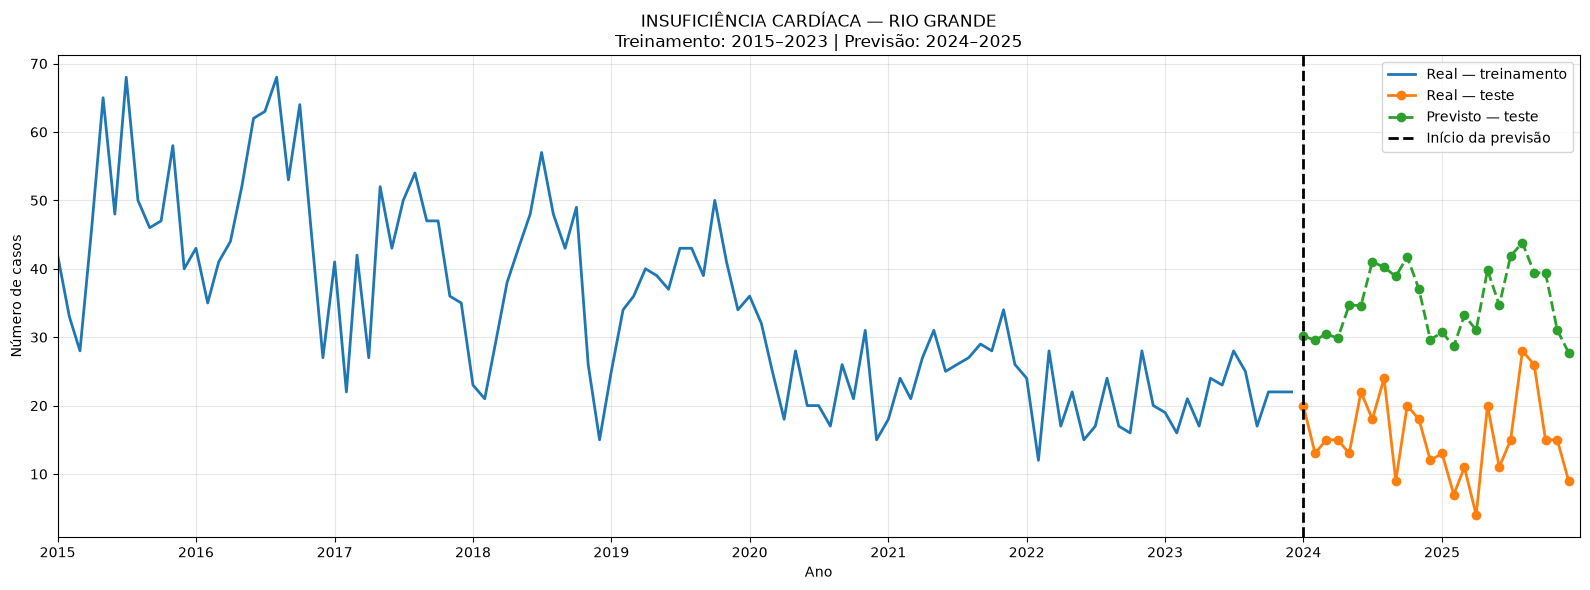

In [27]:
plot_backtest("RIO GRANDE")

### C) Baseline vs modelo climático (Porto Alegre, 2024–2025)

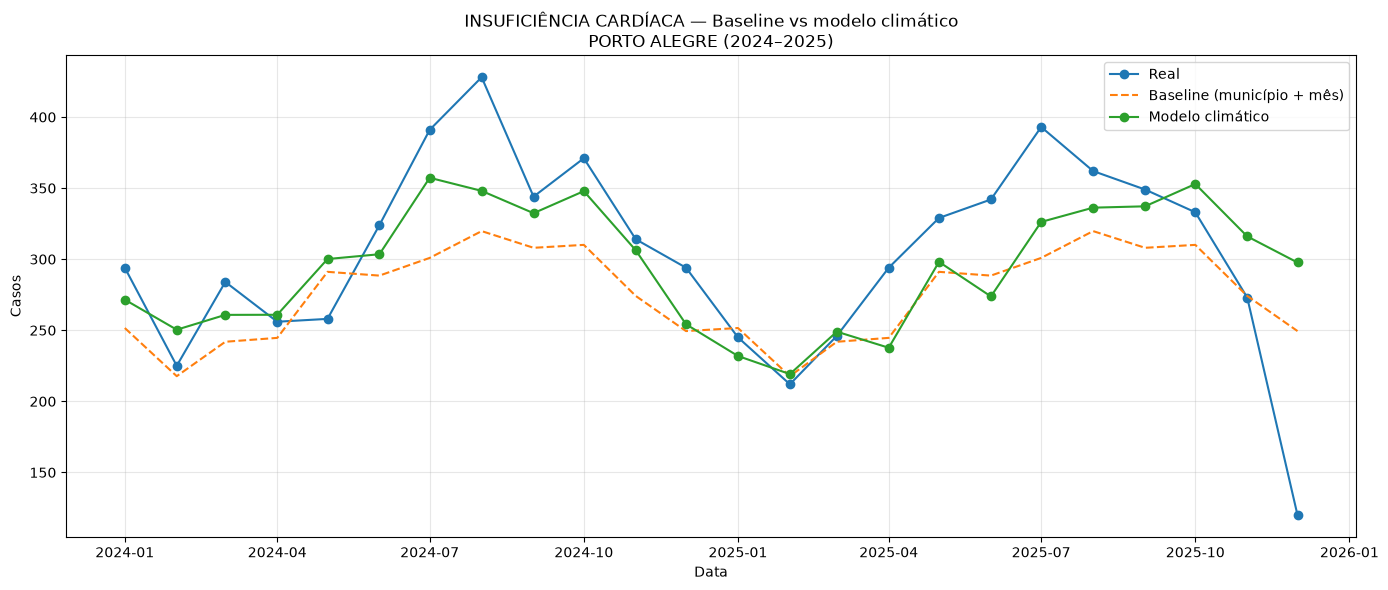

In [28]:
plot_df = resultado["test_final"][resultado["test_final"]["municipality"] == "PORTO ALEGRE"].copy()

plot_df["baseline_pred"] = resultado["base_model"].predict(plot_df)
plot_df["climate_pred"] = resultado["final_model"].predict(plot_df)

mu.plot_baseline_vs_climate(DISEASE, "PORTO ALEGRE", plot_df)

### D) Tabela de métricas por município

**Atenção:** MAE, RMSE e WAPE por município não são "acurácia" — em municípios com poucos casos ou
meses com zero casos, pequenos erros absolutos podem gerar WAPE muito alto ou baixo sem refletir a
real qualidade do modelo.


In [29]:
evaluation_df = resultado["test_final"][["municipality", "reference_date", "cases"]].copy()
evaluation_df["prediction"] = resultado["final_pred"]

municipality_metrics = mu.municipality_metrics_table(evaluation_df)
display(municipality_metrics)

,municipality,n,mean_cases,mae,rmse,wape_pct,r2
0,CAMBARA DO SUL,24,0.541667,0.612386,0.718386,113.055836,-0.035753
1,TORRES,3,3.000000,1.379514,1.393742,45.983807,-1.913775
2,CANELA,21,2.666667,1.977785,2.154153,74.166923,-0.029379
3,TRAMANDAI,20,5.100000,1.966511,2.443291,38.559033,0.019758
4,LAGOA VERMELHA,24,1.875000,2.196421,2.471353,117.142433,-0.176185
5,BENTO GONCALVES,20,5.000000,2.112183,2.680658,42.243670,-1.113508
6,TEUTONIA,19,3.052632,2.384296,2.691774,78.106258,-1.812557
7,CAMPO BOM,21,6.190476,2.365289,2.949568,38.208515,-0.176895
8,FREDERICO WESTPHALEN,24,5.583333,2.332404,3.001167,41.774401,-0.423719
9,RIO PARDO,24,2.583333,2.606162,3.012326,100.883679,-2.308029


## 12. Municípios excluídos do backtest

Municípios presentes no teste mas ausentes no treino válido do modelo final (dropna na feature
selecionada) são excluídos do backtest e listados explicitamente.


In [30]:
excluded_municipalities = mu.unseen_municipalities(resultado["train_final"], resultado["test_final"])
print("Municípios excluídos do backtest:", excluded_municipalities if excluded_municipalities else "nenhum")

Municípios excluídos do backtest: nenhum


## 13. Interpretação final

O modelo de município + mês já explica a maior parte da variação nos casos, dado o forte
componente estrutural e sazonal da série. Das 9 variáveis climáticas testadas, três — pressão
atmosférica, umidade relativa e ponto de orvalho — combinaram significância estatística com ganho
preditivo real na validação de 2023. Como a dupla pressão + ponto de orvalho teve o melhor ganho
de RMSE (sem perder significância) e umidade relativa não agregou valor adicional, o conjunto
final é `atmospheric_pressure_avg_mb` + `dew_point_avg_c` — plausível epidemiologicamente (tônus
vascular, viscosidade sanguínea e estresse térmico). Defasagens não agregaram valor sobre as
versões contemporâneas.

Temperatura, vento e precipitação não trouxeram ganho real. O modelo final convergiu com alpha
estimado, e todos os 27 municípios da doença estavam presentes em treino e teste.

**Sobre a correção metodológica:** o ganho do modelo final no teste 2024–2025 (MAE ≈ 3,00%, RMSE
≈ 3,89%) é menor do que o da primeira versão do notebook (MAE ≈ 4,04%, RMSE ≈ 7,45%, com uma única
variável) — resultado esperado e correto de eliminar o viés de reutilizar o mesmo teste tanto para
escolher variáveis quanto para reportar performance, não uma piora a corrigir. A maior parte da
capacidade preditiva do modelo vem dos efeitos fixos de município e mês, não das variáveis
climáticas isoladamente. Os resultados descrevem associações estatísticas e contribuições
preditivas fora da amostra — não relações causais.


## 14. Persistência de artefatos

Os artefatos são salvos em `artifacts/modeling/insuficiencia_cardiaca_metrics.json` e
`artifacts/modeling/insuficiencia_cardiaca_predictions.parquet`, sem qualquer gravação no
BigQuery.

In [31]:
metrics = {
    "disease": DISEASE,
    "disease_key": "insuficiencia_cardiaca",
    "formula": resultado["formula"],
    "alpha": resultado["alpha"],
    "converged": resultado["final_converged"],
    "base_converged": resultado["base_converged"],
    "aic": final_model.aic,
    "log_likelihood": final_model.llf,
    "coefficients": final_model.params.to_dict(),
    "pvalues": final_model.pvalues.to_dict(),
    "baseline_mae": resultado["base_metrics"]["mae"],
    "baseline_rmse": resultado["base_metrics"]["rmse"],
    "model_mae": resultado["final_metrics"]["mae"],
    "model_rmse": resultado["final_metrics"]["rmse"],
    "mae_improvement_pct": resultado["mae_improvement_pct"],
    "rmse_improvement_pct": resultado["rmse_improvement_pct"],
    "r2_test": resultado["final_metrics"]["r2"],
    "wape_pct": resultado["final_metrics"]["wape_pct"],
    "train_n": len(resultado["train_final"]),
    "test_n": len(resultado["test_final"]),
    "selected_features": features_selecionadas,
    "climate_variable_tests": climate_results.to_dict("records"),
    "lag_variable_tests": lag_results.to_dict("records"),
    "excluded_municipalities": list(excluded_municipalities),
    "feature_selection_validation_period": "2023-01-01 a 2023-12-01 (train_disease_fs = 2015-2022)",
    "feature_selection_rationale": (
        "Selecao de variaveis/lags feita com mu.feature_selection_split: treino em "
        "train_disease_fs (2015-2022), validacao em validation_disease_fs (2023) - nunca em "
        "test_disease0 (2024-2025), para evitar o vies de usar o mesmo periodo tanto para "
        "escolher variaveis quanto para reportar performance final. Tres variaveis combinaram "
        "significancia estatistica com ganho real fora da amostra na validacao: "
        "atmospheric_pressure_avg_mb (MAE -5.85%, RMSE -12.54%, p ~ 0.028), "
        "relative_humidity_avg_pct (MAE -1.66%, RMSE -2.07%, p < 0.0001) e dew_point_avg_c "
        "(MAE -1.11%, RMSE -2.82%, p < 0.0001). A correlacao entre as tres e baixa "
        "(multicolinearidade nao e uma preocupacao forte), mas a combinacao "
        "atmospheric_pressure_avg_mb + dew_point_avg_c apresentou o melhor ganho de RMSE na "
        "validacao (~ -26.9%) com ambos os coeficientes altamente significativos; adicionar "
        "relative_humidity_avg_pct nao trouxe ganho adicional relevante e reduziu a "
        "significancia de dew_point_avg_c. Por isso o conjunto final e "
        "atmospheric_pressure_avg_mb + dew_point_avg_c (ambas contemporaneas, sem lag). "
        "Temperatura, vento e precipitacao, em todas as formas testadas, nao agregaram valor "
        "preditivo real na validacao. O modelo final continua treinado em train_disease0 "
        "(2015-2023) e avaliado em test_disease0 (2024-2025), sem nenhuma mudanca nesse "
        "contrato; o ganho reportado no teste (MAE -3.00%, RMSE -3.89%) e menor do que o da "
        "versao anterior deste notebook (MAE -4.04%, RMSE -7.45%, selecionada olhando para o "
        "proprio 2024-2025), o que e o resultado esperado e correto de remover o vazamento."
    ),
}

predictions_df = resultado["test_final"][["municipality", "reference_date", "cases"]].copy()
predictions_df["prediction"] = resultado["final_pred"]

mu.save_disease_artifacts("insuficiencia_cardiaca", metrics, predictions_df)

print("Artefatos salvos em:", mu.ARTIFACTS_DIR)
print((mu.ARTIFACTS_DIR / "insuficiencia_cardiaca_metrics.json").exists())
print((mu.ARTIFACTS_DIR / "insuficiencia_cardiaca_predictions.parquet").exists())

Artefatos salvos em: C:\Users\eduar\Desktop\Projeto-Python\epidemiological-intelligence\artifacts\modeling
True
True
